In [ ]:
%pip install -r ../requirements.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier

from modules.pca import plot_pca
from modules.tsne import plot_tsne
from modules.umap import plot_umap
from modules.alpha_div import plot_shannon

In [2]:
from pathlib import Path
import sys
import os
# Папка, где лежит ноутбук 
nb_dir = Path(os.getcwd()).resolve()
print("NB_DIR:", nb_dir)


# Корень проекта = родительская папка 
project_root = nb_dir.parent
print("PROJECT_ROOT:", project_root)

# Добавляем папку ноутбука 
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))

# Добавляем корень проекта 
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

NB_DIR: /home/daria/github_HiddenMatter/notebooks
PROJECT_ROOT: /home/daria/github_HiddenMatter


Download tables of results from **Metaphlan**  `abundance_table`  
Make a taxon an index  
Join tables by taxon  

In [63]:
me_il = pd.read_csv("../data/metaphlan_merged_abundance_table_il.txt", sep="\t", skiprows=1)
me_he = pd.read_csv("../data/metaphlan_merged_abundance_table_he.txt", sep="\t", skiprows=1)
me_he = me_he.set_index("clade_name")
me_il = me_il.set_index('clade_name')
me_all = pd.concat([me_il, me_he], axis=1).fillna(0)

Create metadata with sample group 

In [64]:
meta_il = pd.DataFrame({'sample': me_il.columns, 'group': 'disease'})
meta_he = pd.DataFrame({'sample': me_he.columns, 'group': 'healthy'})
meta = pd.concat([meta_il, meta_he], ignore_index=True)
meta = meta.set_index('sample')

Taxonomic level selection

In [65]:
me_sp = me_all[me_all.index.str.contains(r"\|s__")].copy()
me_sp['taxon'] = me_sp.index.str.split('|').str[-1]
me_sp = me_sp.set_index('taxon')
me_sp.index = me_sp.index.str.replace('s__', '', regex=False)
me_sp = me_sp[~me_sp.index.str.startswith('t__')]
me_sp = me_sp[~me_sp.index.astype(str).str.contains("GGB", na=False)]

Group by healthy/disease.  
For average abundance by group

In [66]:
me_t = me_sp.T
me_t["group"] = meta["group"]
grouped_full = me_t.groupby("group").mean()

In [67]:
me_t

taxon,Bacteroides_stercoris,Phocaeicola_vulgatus,Alistipes_onderdonkii,Bacteroides_ovatus,Faecalibacterium_SGB15346,Paraprevotella_clara,Alistipes_putredinis,Roseburia_faecis,Faecalibacterium_prausnitzii,Fusicatenibacter_saccharivorans,...,Bacteroides_sp_Marseille_P3684,Parasutterella_secunda,Megasphaera_sp_NM10,Ruminococcus_champanellensis,Oscillospiraceae_unclassified_SGB15257,Parabacteroides_faecalis,Tractidigestivibacter_montrealensis,Kluyvera_ascorbata,Citrobacter_freundii,group
SRR11047625,24.001222,8.520445,8.320998,7.871502,4.751939,4.659933,3.255442,2.465963,2.415300,2.237330,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,disease
SRR11047626,39.292749,12.918639,1.310468,0.000000,0.732468,0.000000,0.000000,0.538733,3.181598,0.260697,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,disease
SRR11047627,0.000000,0.000000,11.697491,0.119947,0.128961,0.000000,2.747220,0.186627,5.457118,3.315795,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,disease
SRR11047628,0.000000,25.421494,3.841153,2.172774,0.230760,0.000000,0.000000,0.771783,1.476637,0.424998,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,disease
SRR11047629,0.000000,7.058891,0.116516,1.894746,0.345093,0.000000,5.964344,3.086081,5.642422,0.484977,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR2784817,0.760453,8.957772,0.068848,0.168242,0.027758,0.108246,2.598763,0.399256,2.600161,0.222511,...,1.521745,0.662459,0.382183,0.184721,0.066374,0.023077,0.009327,0.000000,0.000000,healthy
ERR2784818,0.727233,8.200133,0.067475,0.119943,0.024366,0.097552,2.497938,0.364950,2.468625,0.204562,...,1.513529,0.692145,0.422275,0.208826,0.059071,0.029776,0.000000,0.000000,0.000000,healthy
ERR2784824,0.000000,4.936493,1.494431,1.308595,0.000000,0.000000,5.617337,1.345850,1.625966,0.363015,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007260,0.000000,healthy
ERR2784826,0.000000,4.805677,1.417258,1.368141,0.000000,0.000000,5.396493,1.299293,1.493642,0.336009,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008034,0.025762,healthy


In [33]:
me_rel = me_sp.div(me_sp.sum(axis=0), axis=1) * 100

# top taxa
top_taxa = (
    me_rel.sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
)

me_top = me_rel.loc[top_taxa]

# Other
other = me_rel.drop(top_taxa).sum(axis=0)

me_top.loc["Other"] = other
me_top_t = me_top.T

me_top_t["group"] = meta["group"]

grouped = me_top_t.groupby("group").mean()

Plot for Mean relative abundance

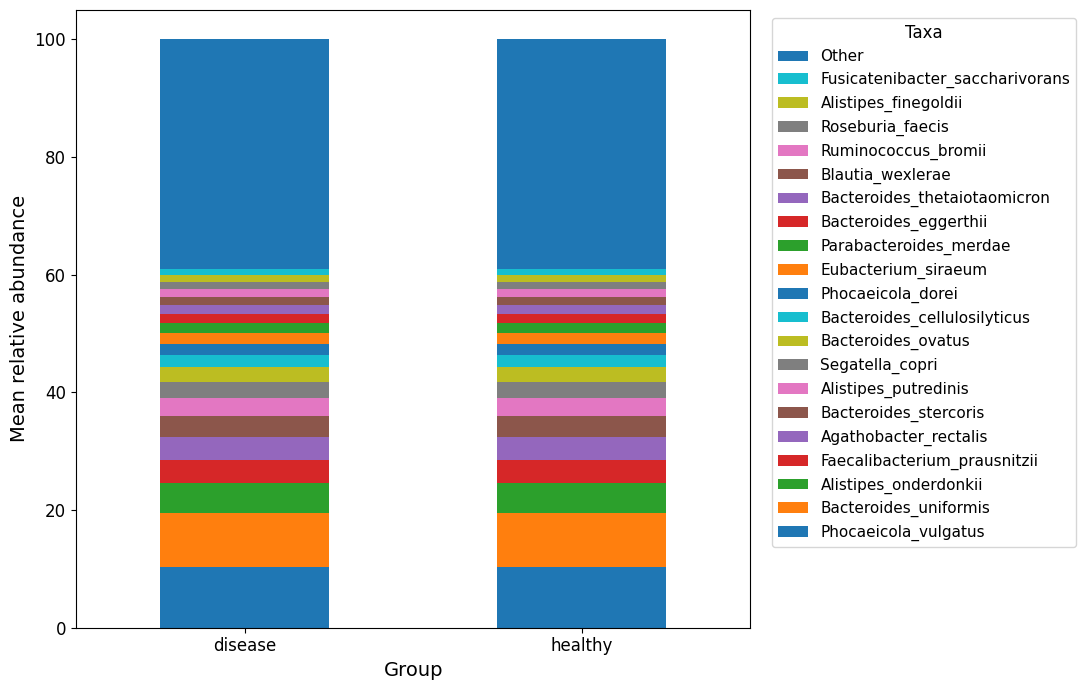

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

grouped.plot(kind="bar", stacked=True, ax=ax)

ax.set_ylabel("Mean relative abundance", fontsize=14)
ax.set_xlabel("Group", fontsize=14)

ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
    title="Taxa",
    title_fontsize=12
)

# plt.title('Microbial abundance Metaphlan', fontsize=20)

plt.tight_layout()
plt.savefig('../results/mean_rel_abund100_metaphlan.png', dpi=300)
plt.show()

PCA

In [37]:
me_t = me_t.drop('group', axis=1)

In [46]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


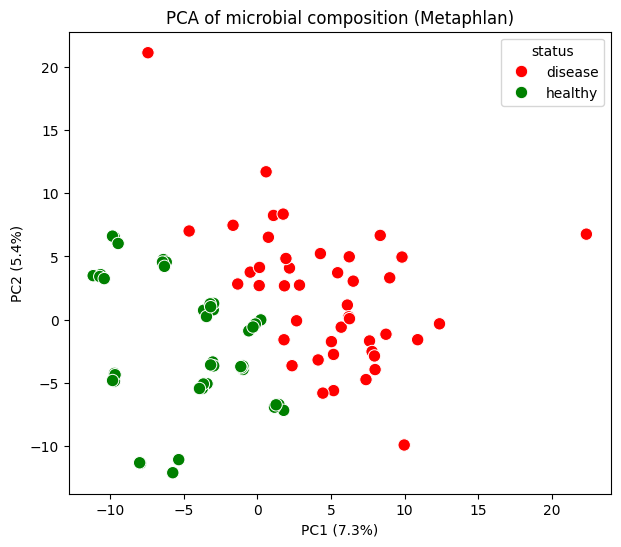

In [ ]:
pca_df, pca = plot_pca(me_t, meta, method="Metaphlan")

t-SNE

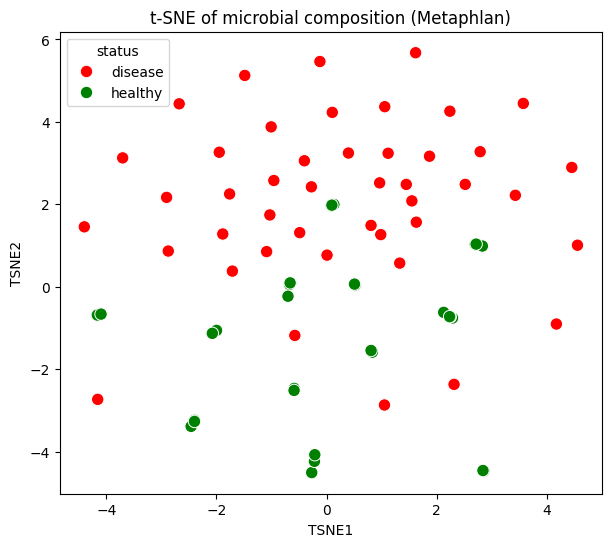

In [ ]:
df_tsne, tsne = plot_tsne(me_t, meta, method="Metaphlan")

UMAP

/home/daria/github_HiddenMatter/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


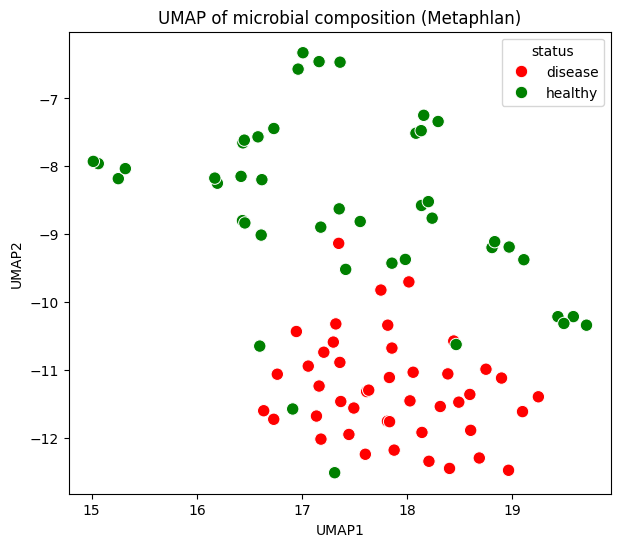

In [ ]:
df_umap, umap = plot_umap(me_t, meta, method="Metaphlan")

Alpha diversity

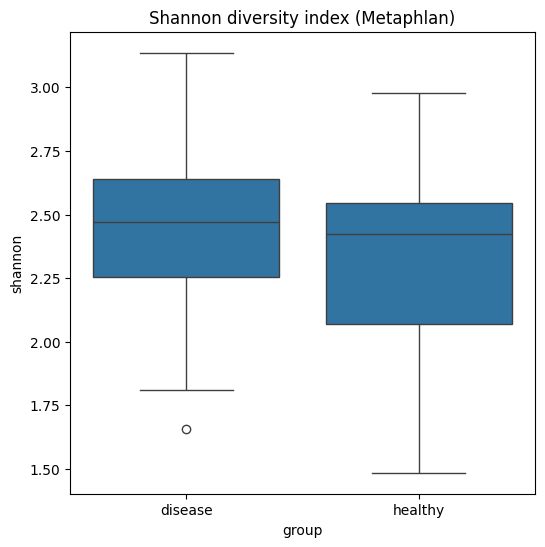

In [49]:
from modules.alpha_div import plot_shannon

shannon_df = plot_shannon(me_t, meta, method="Metaphlan")

ML  
Logistic regression

In [ ]:
me_t

In [51]:
# Preprocessing and filtration

X = me_t.copy()
y = meta["group"]
X = X.loc[y.index]
prevalence = (X > 0).mean(axis=0)
X = X.loc[:, prevalence >= 0.10]
mean_abundance = X.mean(axis=0)
X = X.loc[:, mean_abundance >= 1e-5]

# CLR transformation

def clr_transform(df, pseudocount=1e-6):
    X_pc = df + pseudocount
    log_X = np.log(X_pc)
    clr = log_X.sub(log_X.mean(axis=1), axis=0)
    return clr

X_clr = clr_transform(X)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clr,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        l1_ratio=0.5, 
        C=1.0, 
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9, 1.0]
}

In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best params: {'model__C': 0.1, 'model__l1_ratio': 0.1}
Best CV ROC-AUC: 1.0


In [55]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

     disease       1.00      1.00      1.00         9
     healthy       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Test ROC-AUC: 1.0
Confusion matrix:
[[9 0]
 [0 9]]


In [56]:
# Importance taxons

coef = best_model.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "taxon": X_clr.columns,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

importance.head(30)

,taxon,coef,abs_coef
158,Adlercreutzia_equolifaciens,-0.204959,0.204959
65,Holdemania_filiformis,-0.168101,0.168101
200,Parabacteroides_distasonis,0.159672,0.159672
214,Odoribacter_splanchnicus,0.152283,0.152283
255,Alistipes_hominis,0.146589,0.146589
125,Lactococcus_lactis,-0.135318,0.135318
57,Monoglobus_pectinilyticus,-0.133334,0.133334
166,Eggerthella_lenta,-0.132122,0.132122
156,Lachnospiraceae_bacterium,-0.128064,0.128064
258,Prevotellamassilia_timonensis,0.126658,0.126658


Random Forest

In [61]:
me_t

taxon,Bacteroides_stercoris,Phocaeicola_vulgatus,Alistipes_onderdonkii,Bacteroides_ovatus,Faecalibacterium_SGB15346,Paraprevotella_clara,Alistipes_putredinis,Roseburia_faecis,Faecalibacterium_prausnitzii,Fusicatenibacter_saccharivorans,...,Leyella_lascolaii,Bacteroides_sp_Marseille_P3684,Parasutterella_secunda,Megasphaera_sp_NM10,Ruminococcus_champanellensis,Oscillospiraceae_unclassified_SGB15257,Parabacteroides_faecalis,Tractidigestivibacter_montrealensis,Kluyvera_ascorbata,Citrobacter_freundii
SRR11047625,24.001222,8.520445,8.320998,7.871502,4.751939,4.659933,3.255442,2.465963,2.415300,2.237330,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR11047626,39.292749,12.918639,1.310468,0.000000,0.732468,0.000000,0.000000,0.538733,3.181598,0.260697,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR11047627,0.000000,0.000000,11.697491,0.119947,0.128961,0.000000,2.747220,0.186627,5.457118,3.315795,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR11047628,0.000000,25.421494,3.841153,2.172774,0.230760,0.000000,0.000000,0.771783,1.476637,0.424998,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SRR11047629,0.000000,7.058891,0.116516,1.894746,0.345093,0.000000,5.964344,3.086081,5.642422,0.484977,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR2784817,0.760453,8.957772,0.068848,0.168242,0.027758,0.108246,2.598763,0.399256,2.600161,0.222511,...,2.645292,1.521745,0.662459,0.382183,0.184721,0.066374,0.023077,0.009327,0.000000,0.000000
ERR2784818,0.727233,8.200133,0.067475,0.119943,0.024366,0.097552,2.497938,0.364950,2.468625,0.204562,...,2.610280,1.513529,0.692145,0.422275,0.208826,0.059071,0.029776,0.000000,0.000000,0.000000
ERR2784824,0.000000,4.936493,1.494431,1.308595,0.000000,0.000000,5.617337,1.345850,1.625966,0.363015,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007260,0.000000
ERR2784826,0.000000,4.805677,1.417258,1.368141,0.000000,0.000000,5.396493,1.299293,1.493642,0.336009,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008034,0.025762


In [ ]:
X = me_t
y = meta["group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [2, 5],
    "min_samples_leaf": [20, 50],
    "min_samples_split": [50, 100],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

In [ ]:
print('Best params', grid.best_params_)
print("Classification report")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params {'class_weight': 'balanced', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 50, 'n_estimators': 300}
Classification report
              precision    recall  f1-score   support

     disease       1.00      0.11      0.20         9
     healthy       0.53      1.00      0.69         9

    accuracy                           0.56        18
   macro avg       0.76      0.56      0.45        18
weighted avg       0.76      0.56      0.45        18

[[1 8]
 [0 9]]


In [ ]:
feature_counts = pd.Series(0, index=X.columns, dtype=int)

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        **grid.best_params_,
        random_state=42
    )
    model.fit(X_tr, y_tr)

    importances = pd.Series(
        model.feature_importances_,
        index=X.columns
    )

    top_features = importances.sort_values(ascending=False).head(20).index
    feature_counts.loc[top_features] += 1

stable_features = feature_counts.sort_values(ascending=False).head(30)
print(stable_features)

taxon
Blautia_sp_OF03_15BH               99
Senegalimassilia_anaerobia         98
Clostridium_disporicum             95
Bacteroides_cutis                  93
Butyricimonas_virosa               92
Blautia_stercoris                  91
Collinsella_tanakaei               90
Catenibacterium_tridentinum        85
Eshraghiella_crossota              82
Hungatella_hathewayi               81
Desulfovibrio_desulfuricans        75
Collinsella_stercoris              69
Segatella_copri                    64
Phocaeicola_dorei                  64
Slackia_SGB14781                   58
Rikenellaceae_bacterium            50
Clostridium_fessum                 49
Mediterraneibacter_faecis          38
Hominenteromicrobium_mulieris      38
Clostridium_leptum                 37
Enterocloster_aldenensis           32
Jutongia_huaianensis               31
Bacteroides_uniformis              27
Faecalibacterium_prausnitzii       26
Flintibacter_hominis               25
Clostridium_sp_AM22_11AC           24
Pilosi

In [70]:
y_pred = model.predict(X_test)

In [ ]:
print("Classification report")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Classification report
              precision    recall  f1-score   support

     disease       1.00      0.67      0.80         9
     healthy       0.75      1.00      0.86         9

    accuracy                           0.83        18
   macro avg       0.88      0.83      0.83        18
weighted avg       0.88      0.83      0.83        18

[[6 3]
 [0 9]]
